## Setting things up

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, 'C:\\Users/jnka0003/Git repos/CIBUSmod')

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Set up scenarios

In [10]:
# Create session
session = cm.Session(
    name = 'FORMAS', # <--- Make sure that name and data_path match with multi_proc.py
    data_path = 'C:\\Users/jnka0003/Git repos/CIBUSmod/data',
    data_path_scenarios = 'scenarios',
    data_path_output = 'output',
)
# cm.ParameterRetriever.data_path_scenarios = os.path.join('scenarios')

# Define scenarios

session.add_scenario(
    name = 'baseline',
    scenario_workbooks = None, 
    modules = 'all',
    pars = 'all',
    years = 0
)
session.add_scenario(
    name = 'cur',
    scenario_workbooks = 'sng_area', 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)
session.add_scenario(
    name = 'steers',
    scenario_workbooks = ['sng_area', 'steers'], 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)
session.add_scenario(
    name = 'retired cows',
    scenario_workbooks = ['sng_area', 'ret_cows'], 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)
session.add_scenario(
    name = 'winter lambs',
    scenario_workbooks = ['sng_area', 'wint_lamb'], 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)
session.add_scenario(
    name = 'all combined',
    scenario_workbooks = ['sng_area', 'steers', 'ret_cows', 'wint_lamb'], 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)

A scenario with the name 'baseline' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'cur' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'steers' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'retired cows' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'winter lambs' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'all combined' already exists use .update_scenario() or .remove_scenario() instead.


## Plot results

In [62]:
# Common style for plots
bar_style = {
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey',
    'bar_width' : 0.6
}

bar_style_one = {
    'color' : 'lightgrey',
    'edgecolor' : 'grey'
}

map_style = {
    'cmap' : 'YlOrBr',
    'edgecolor' : 'grey'
}

map_style_r = map_style.copy()
map_style_r['cmap'] = map_style_r['cmap'] + '_r'

map_style_div = {
    'cmap' : 'BrBG',
    'edgecolor' : 'grey'
}

# Get final iteration of each scenario
scn_final = [(scn, '110' if '110' in years else '0') for scn, years in session.scenarios('has output').items()]

rename_years = {
    '0' : '',
    '70' : '-30% CH4',
    '100' : '+/-0% CH4',
    '110' : '+10% CH4'
}

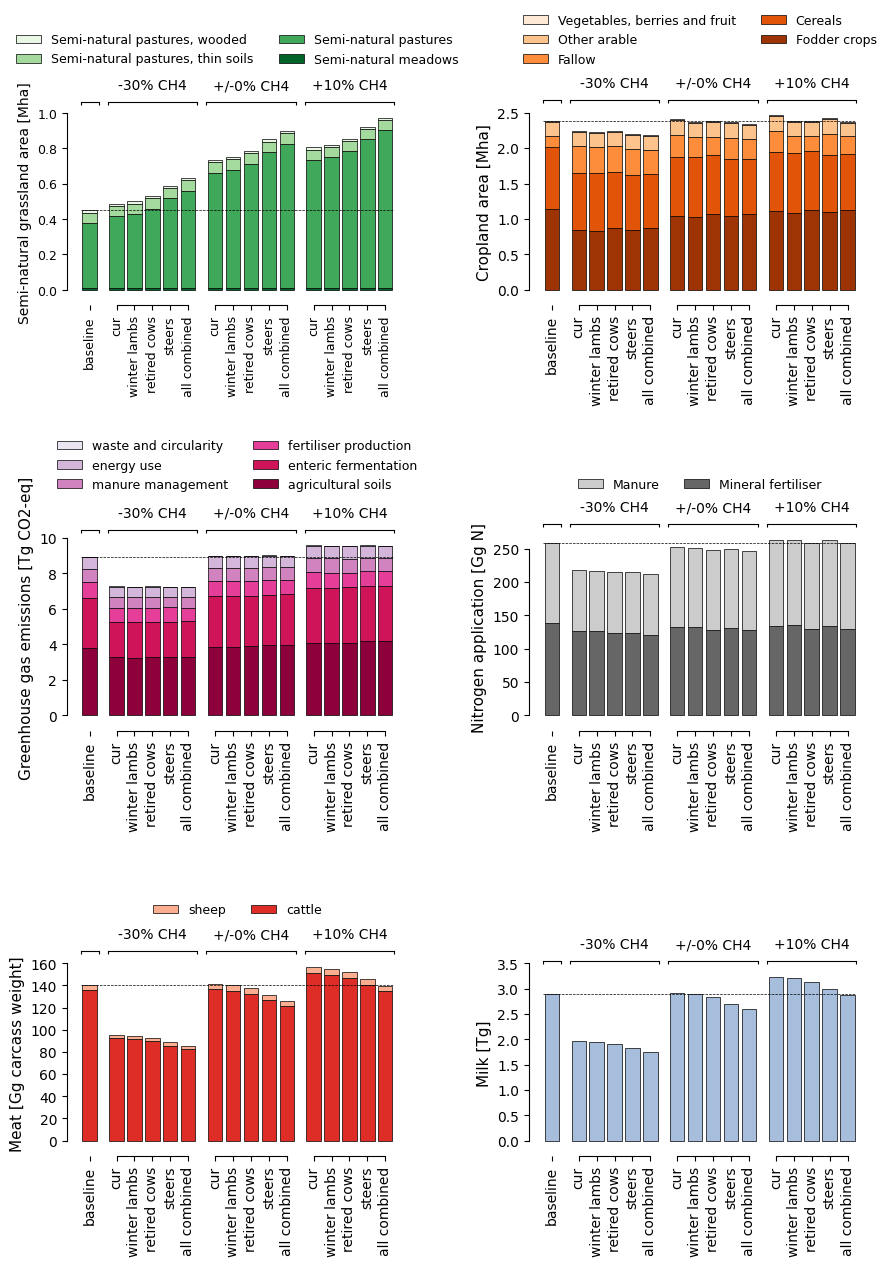

In [63]:
fig, axs = plt.subplots(3,2, figsize=(9,13))

# SNG AREA ---------------------------------------------------------------------- ##

ax=axs[0,0]
plot_data = (
    session.get_attr('c','area',{'crop':['land_use',None]})
    .loc[:,'semi-natural grasslands']
    .rename(rename_years)
)/1000000
sort = plot_data.sum(axis=1).sort_values().index

cm.plot.bar(
    plot_data.loc[sort],
    ax=ax,
    group_levels='year',
    sort_xlabels=False,
    sort_groups=False,
    cmap='Greens',
    ylabel='Semi-natural grassland area [Mha]',
    ylabel_fontsize=10,
    grouplabels_fontsize=10,
    ticklabels_fontsize=9
)
ax.axhline(plot_data.loc[('baseline','')].sum(), c='black', linewidth=0.5, linestyle='--')

# CROP AREA ---------------------------------------------------------------------- ##

ax = axs[0,1]
plot_data = (
    session.get_attr('c','area',{'crop':['land_use','crop_group2']})
    .loc[:,'cropland']
    .rename(rename_years)
)/1000000
cm.plot.bar(
    plot_data.loc[sort],
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap='Oranges',
    ylabel='Cropland area [Mha]'
)
ax.axhline(plot_data.loc[('baseline','')].sum(), c='black', linewidth=0.5, linestyle='--')

# GHG ---------------------------------------------------------------------- ##

ax = axs[1,0]
plot_data = (
    cm.get_GHG(session, CO2eq = True)
    .T.groupby('process').sum().T
    .rename(rename_years)
)/1000000000
cm.plot.bar(
    plot_data.loc[sort],
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap='PuRd',
    ylabel='Greenhouse gas emissions [Tg CO2-eq]'
)
ax.axhline(plot_data.loc[('baseline','')].sum(), c='black', linewidth=0.5, linestyle='--')

# N FERTILISER ---------------------------------------------------------------------- ##

ax = axs[1,1]
plot_data = (
    pd.concat([
        session.get_attr('c','fertiliser.mineral_N', 'none').rename('Mineral fertiliser'),
        session.get_attr('c','fertiliser.manure_N', 'none').rename('Manure')
    ], axis=1)
    .rename(rename_years)
)/1000000
from matplotlib.colors import ListedColormap
cm.plot.bar(
    plot_data.loc[sort],
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#666666','#cccccc']),
    ylabel='Nitrogen application [Gg N]'
)
ax.axhline(plot_data.loc[('baseline','')].sum(), c='black', linewidth=0.5, linestyle='--')

# MEAT AND MILK ---------------------------------------------------------------------- ##

plot_data = (
    session.get_attr('a','prod', ['animal_prod','species'])
    .loc[:,(slice(None),['cattle','sheep'])]
    .rename(rename_years)
)/1000000
ax = axs[2,0]
cm.plot.bar(
    plot_data.loc[:,'meat'].loc[sort],
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#de2d26','#fcae91']),
    ylabel='Meat [Gg carcass weight]'
)
ax.axhline(plot_data.loc[('baseline',''),'meat'].sum(), c='black', linewidth=0.5, linestyle='--')
ax = axs[2,1]
cm.plot.bar(
    plot_data.loc[:,'milk'].loc[sort]/1000,
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#a6bddb']),
    ylabel='Milk [Tg]'
)
ax.axhline(plot_data.loc[('baseline',''),'milk'].sum()/1000, c='black', linewidth=0.5, linestyle='--')

for ax in axs.flatten()[:-1]:
    ax.legend(loc='lower center', bbox_to_anchor=(0.5,1.2), frameon=False, ncol=2, fontsize=9, reverse=True)

plt.tight_layout()
plt.show()

### Bar plots: Production and animal heads

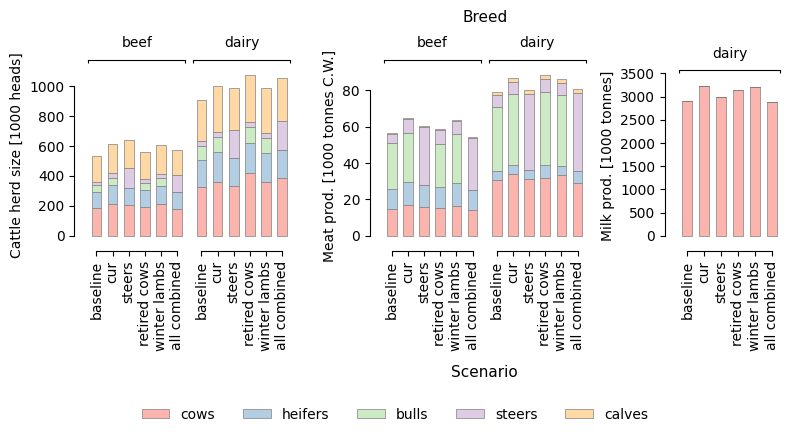

In [64]:
fig, axs = plt.subplots(1,3, figsize=(8,4), width_ratios=(1,1,0.5))

plot_data = (
    session.get_attr('A','heads',['species','animal','breed'])
    .loc[scn_final,:]
    .xs('cattle', level='species', axis=1).droplevel('year')
    .stack()
    .reindex(['cows','heifers','bulls','steers','calves'], level='animal', axis=1)
)/1000

ax=axs[0]
cm.plot.bar(
    plot_data,
    ax=ax, group_levels=['breed'], sort_xlabels=False, sort_categories=False, **bar_style,
    ylabel='Cattle herd size [1000 heads]', ylabel_fontsize=10
)
ax.get_legend().remove()

plot_data = (
    session.get_attr('A','production',['species','animal','animal_prod', 'breed'])
    .loc[scn_final,:]
    .xs('cattle', level='species', axis=1).droplevel('year')
    .stack()
    .reindex(['cows','heifers','bulls','steers','calves'], level='animal', axis=1)
)/1000000

ax = axs[1]
cm.plot.bar(
    plot_data.xs('meat', level='animal_prod', axis=1),
    ax=ax, group_levels='breed', sort_xlabels=False, sort_categories=False, **bar_style,
    grouptitle='Breed', xlabel='Scenario', ylabel='Meat prod. [1000 tonnes C.W.]', ylabel_fontsize=10
)
ax.get_legend().remove()

ax = axs[2]
cm.plot.bar(
    plot_data.drop('beef', level='breed').xs('milk', level='animal_prod', axis=1).reindex(plot_data.columns.unique('animal'), axis=1),
    ax=ax, group_levels='breed', sort_xlabels=False, sort_categories=False, **bar_style,
    ylabel='Milk prod. [1000 tonnes]', ylabel_fontsize=10
)
ax.get_legend().remove()

fig.legend(*axs[0].get_legend_handles_labels(), loc='upper center', bbox_to_anchor=(0.5,0), ncol=5, frameon=False)
plt.tight_layout()
plt.show()

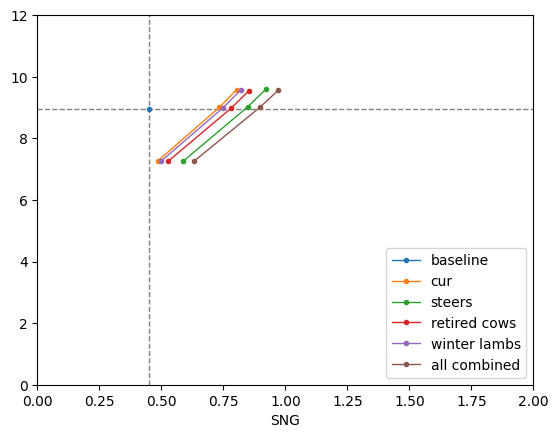

In [65]:
plot_data = pd.concat([
    session.get_attr('c','area',{'crop':'land_use'}).loc[:,'semi-natural grasslands'].rename('SNG')/1000000,
    cm.get_GHG(session).sum(axis=1).rename('GHG')/1000000000
], axis=1).set_index('SNG', append=True)['GHG'].unstack(['scn','year'])

fig,ax = plt.subplots()
ax.axhline(y=plot_data['baseline'].dropna().values, color='grey', linestyle='--', linewidth=1)
ax.axvline(x=plot_data['baseline'].dropna().index.values, color='grey', linestyle='--', linewidth=1)

for scn in plot_data.columns.unique('scn'):
    plot_data.droplevel('year',axis=1).T.groupby('scn').sum().T.replace({0:np.nan}).loc[:,scn].dropna().plot(marker='.', linestyle='-', linewidth=1)

ax.set_xlim([0,2])
ax.set_ylim([0,12])

ax.legend()
plt.show()

In [86]:
plot_data.rename({
    'cold blooded horses':'all',
    'ponies and Icelandic horses' : 'all',
    'riding horses' : 'all',
    'trotters and racehorses' : 'all'
}).groupby(['scn','species','breed']).sum()

KeyError: 'species'

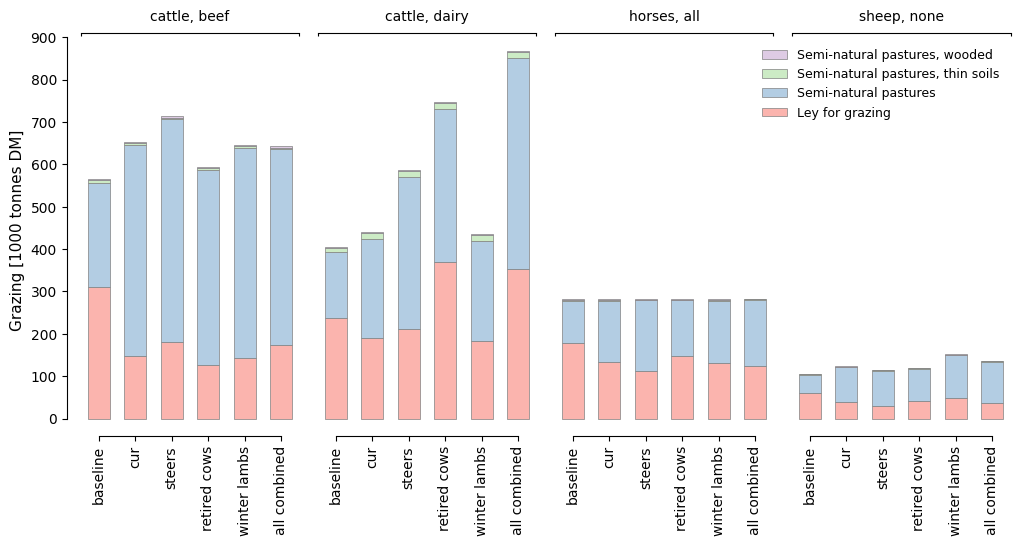

In [92]:
plot_data = (
    session.get_attr('c','production_per_use',['crop','demand'])
    .loc[scn_final,['Ley for grazing', 'Semi-natural pastures', 'Semi-natural pastures, thin soils', 'Semi-natural pastures, wooded']]
    .droplevel('year')
)/1_000_000

plot_data.columns = pd.MultiIndex.from_tuples(
    [(cr,) + tuple(an.replace('feed (','').replace(')','').split(', ')) for cr, an in plot_data.columns],
    names = ['crop', 'species', 'breed', 'sub_system']
)
plot_data = (
    plot_data.T.groupby(['species','breed','crop']).sum().T
    .stack(['species','breed'])
)

# Aggregate horses
plot_data = plot_data.rename({
    'cold blooded horses':'all',
    'ponies and Icelandic horses' : 'all',
    'riding horses' : 'all',
    'trotters and racehorses' : 'all'
}).groupby(['scn','species','breed'], sort=False).sum()

fig,ax = plt.subplots(figsize=(12,5))
d = plot_data#.xs((sp,br,ss), level=('species','breed','sub_system')).dropna(axis=1)
cm.plot.bar(
    d,
    ax=ax,
    group_levels=['species','breed'],
    sort_groups=False,
    sort_xlabels=False,
    sort_categories=False,
    ylabel='Grazing [1000 tonnes DM]',
    **bar_style
)
plt.show()

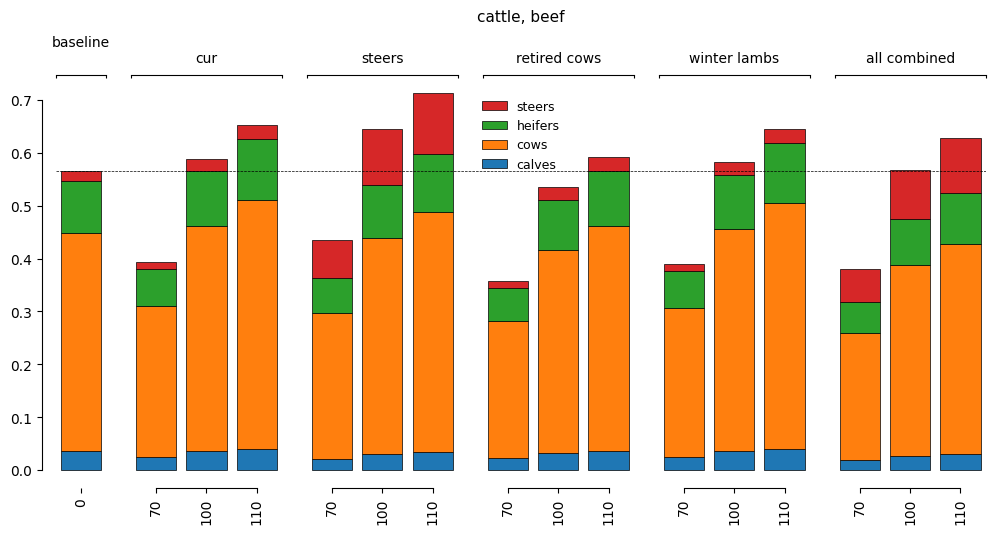

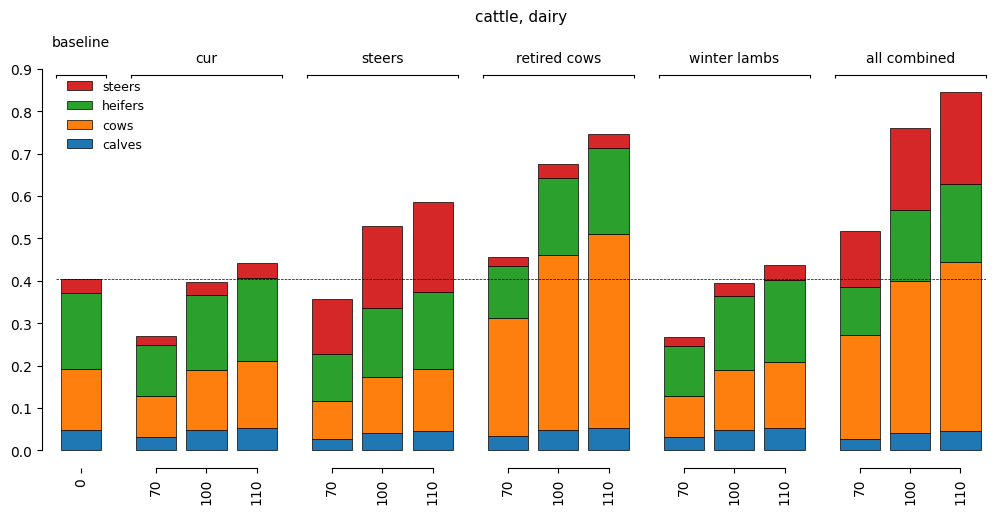

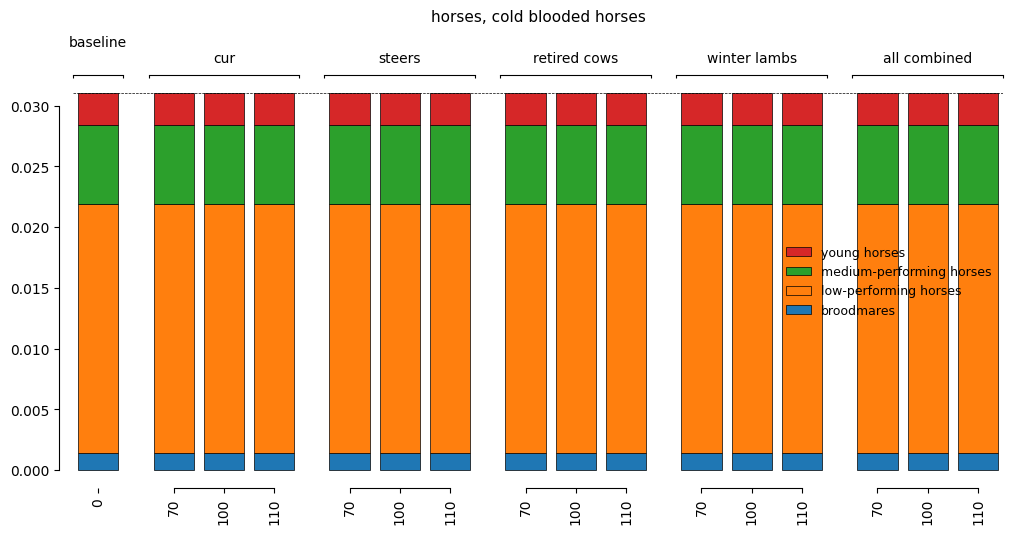

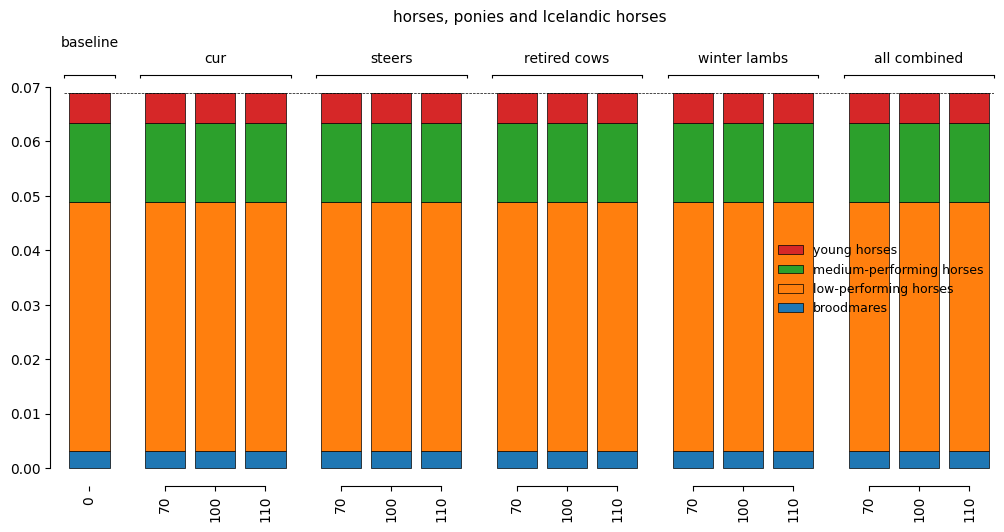

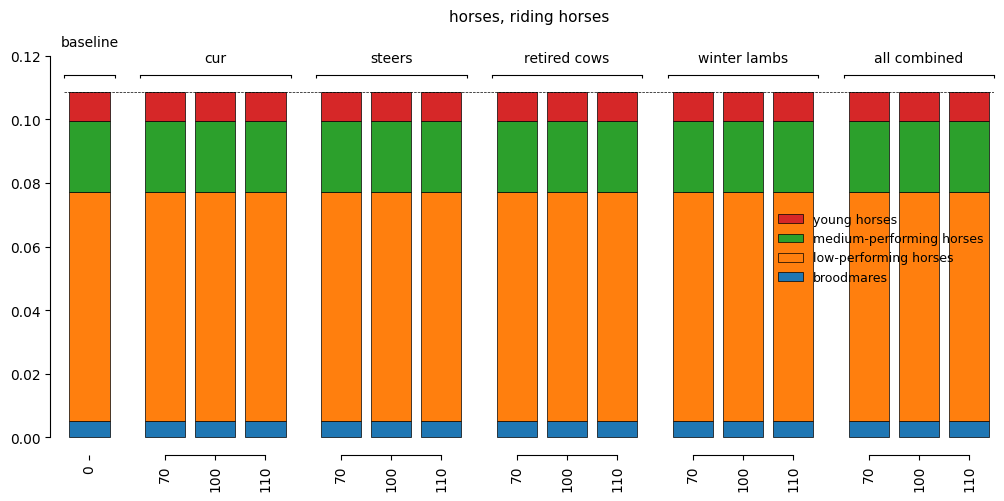

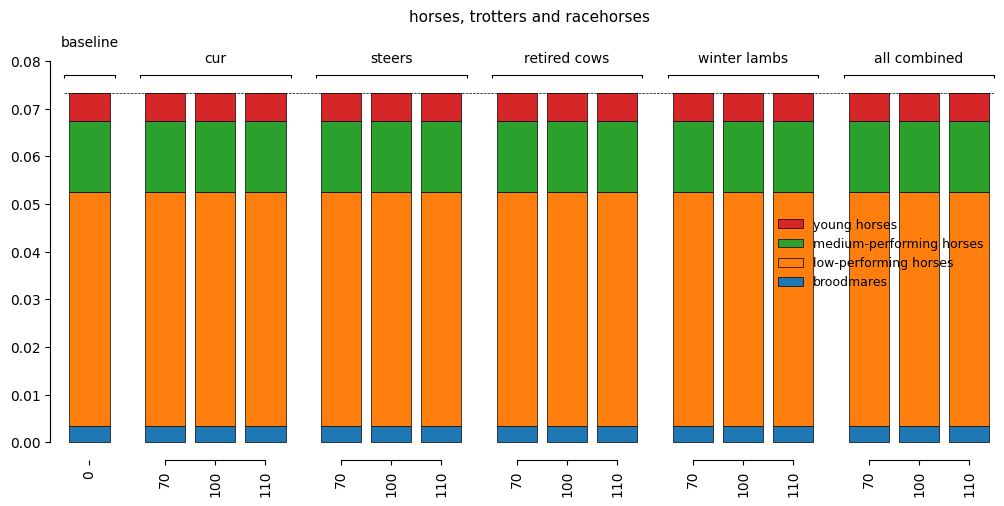

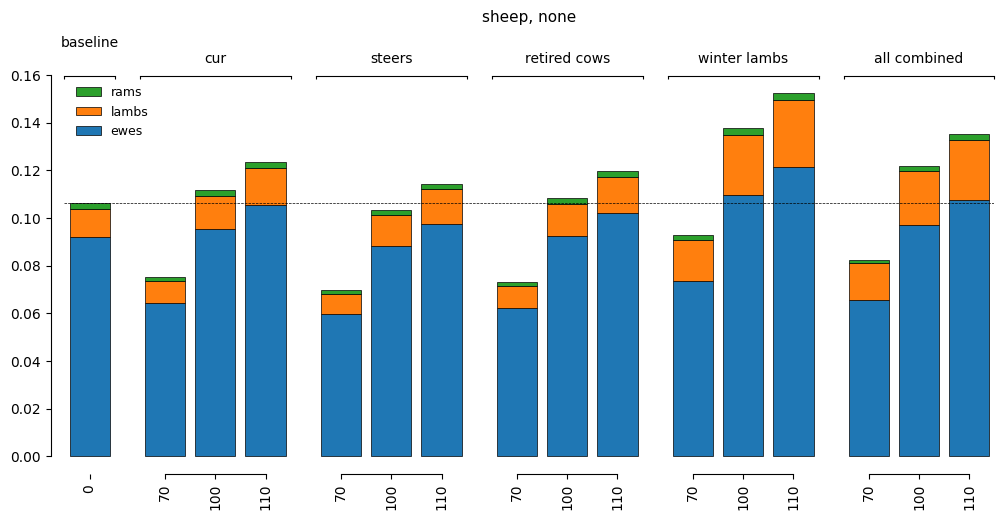

In [152]:
plot_data = (
    session.get_attr('a','feed.crop_prod',['origin','crop_prod','species','breed','animal'])
    .loc[:,'domestic']
    .loc[:,'grazing']
    .stack(['species','breed'])
)/1000000000
for sp,br in plot_data.index.droplevel(['scn','year']).unique():
    fig,ax = plt.subplots(figsize=(12,5))
    d = plot_data.xs((sp,br), level=('species','breed')).dropna(axis=1)
    cm.plot.bar(
        d,
        ax=ax,
        group_levels=['scn'],
        sort_groups=False,
        sort_xlabels=False,
        sort_categories=False,
        grouptitle=f"{sp}, {br}"
    )
    ax.axhline(d.loc['baseline'].sum(axis=1).iloc[0], c='black', linewidth=0.5, linestyle='--')
    plt.show()

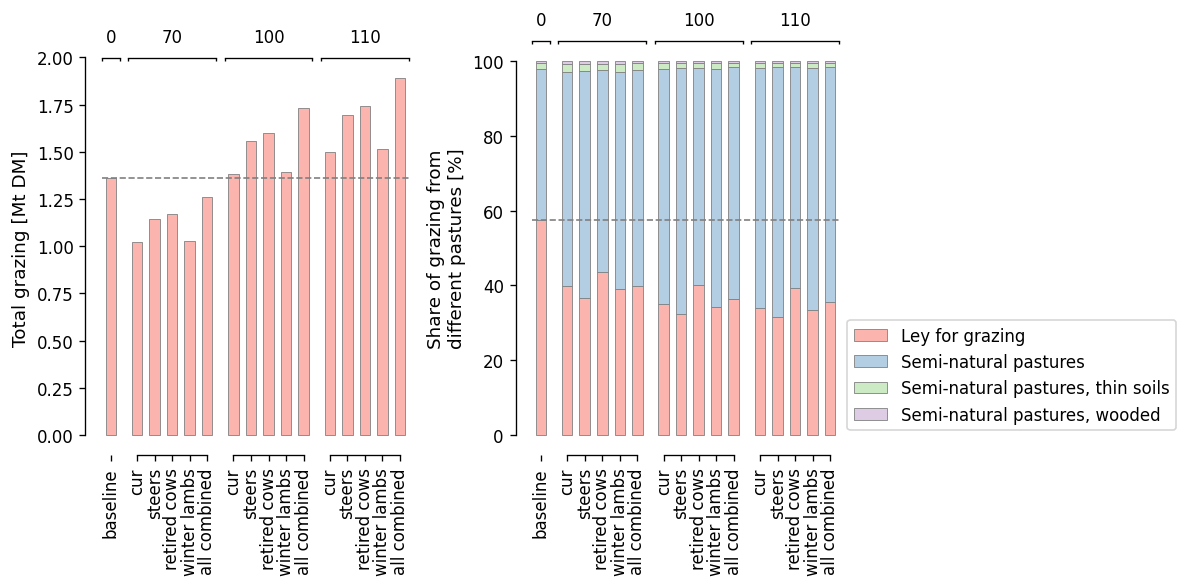

scn           year
baseline      0       42.391793
cur           70      60.273936
              100     64.896491
              110     65.922416
steers        70      63.298265
              100     67.558326
              110     68.506476
retired cows  70      56.289288
              100     59.909485
              110     60.687789
winter lambs  70      61.008835
              100     65.649280
              110     66.676408
all combined  70      60.050299
              100     63.640829
              110     64.427342
Name: Ley for grazing, dtype: float64

In [154]:
grazing = session.get_attr('C', 'production', ['crop_prod','crop']).loc[:,'grazing']
grazing = grazing.loc[:,grazing.sum()!=0]

plot_data1 = (
    grazing
    # .loc[SCN_NAME]
    # .rename(scn_name_map)
    /1000000000
)

plot_data2 = plot_data1.apply(lambda x: x/x.sum()*100, axis=1)

fig,axs = plt.subplots(1,2, figsize=(10,5), dpi=120)
ax=axs[0]
cm.plot.bar(plot_data1.sum(axis=1), group_levels='year', **bar_style, ax=ax, sort_xlabels=False, sort_groups=False)
ax.axhline(y=plot_data1.sum(axis=1).loc['baseline'].iloc[0], linestyle='--', linewidth=1, color='grey')
ax.set_ylabel('Total grazing [Mt DM]')
# ax.set_xlabel('')

ax = axs[1]
cm.plot.bar(plot_data2, group_levels='year', **bar_style, ax=ax, sort_xlabels=False, sort_groups=False, sort_categories=False)
ax.axhline(y=plot_data2.loc['baseline','Ley for grazing'].iloc[0], linestyle='--', linewidth=1, color='grey')
ax.legend(loc='lower left', ncol=1, bbox_to_anchor=(1, 0), fontsize=10)
ax.set_ylabel('Share of grazing from\ndifferent pastures [%]')
# ax.set_xlabel('')

plt.tight_layout()
plt.show()

100-plot_data2.loc[:,'Ley for grazing']

### Bar plots: GHG and land use

### Maps: Land use and cattle numbers

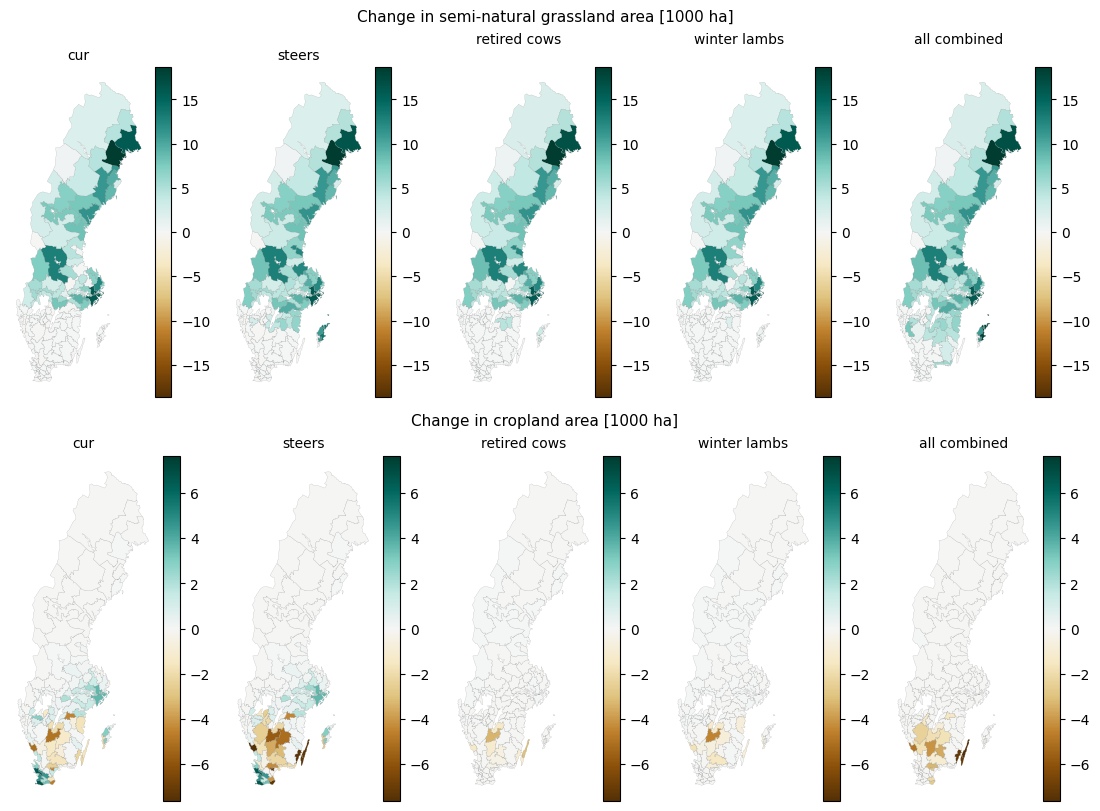

In [13]:
plot_data = (
    session.get_attr('c','area',{'crop':'land_use', 'region':None})
    .loc[scn_final,:]
    .transform(lambda x: x.sub(x.loc[('baseline','0')],axis=1))
    .drop(('baseline','0'))
    .droplevel('year')
)/1000


n_scn = len(plot_data)
lims = plot_data.T.abs().groupby('land_use').max().max(axis=1)

# fig,axs = plot.subplots(plot_data.T.drop('greenhouse'),
#                         size=(2.5,4), columns='scn', index='land_use', title_fontsize=11,
#                         plot_fn=plot.map_from_series,
#                         cmap_zero_midpoint=False, **map_style_div, vmax=8, vmin=-8)
# for ax in axs.flatten():
#     ax.axis('off')
# plt.tight_layout()
# plt.show()

fig = plt.figure(layout='constrained', figsize=(2.2*n_scn, 8))
subfigs = fig.subfigures(2, 1, wspace=0.07)

# Semi-natural grasslands
axs1 = subfigs[0].subplots(1,n_scn)
for n, scn in enumerate(plot_data.index):
    ax = axs1[n]
    cm.plot.map_from_series(
        plot_data.loc[scn,'semi-natural grasslands'],
        ax = ax,
        vmin=-lims.loc['semi-natural grasslands'],
        # cmap_zero_midpoint='shrink',
        vmax=lims.loc['semi-natural grasslands'],
        **map_style_div
    )
    ax.set_title(scn, size=10)
    ax.axis('off')
subfigs[0].suptitle('Change in semi-natural grassland area [1000 ha]', size=11)

# Cropland
axs2 = subfigs[1].subplots(1,n_scn)
# fig, axs = plt.subplots(1,n_scn, figsize=(2.2*n_scn,4))
for n, scn in enumerate(plot_data.index):
    ax = axs2[n]
    cm.plot.map_from_series(
        plot_data.loc[scn,'cropland'],
        ax = ax,
        vmin=-lims.loc['cropland'],
        # cmap_zero_midpoint='shrink',
        vmax=lims.loc['cropland'],
        **map_style_div
    )
    ax.set_title(scn, size=10)
    ax.axis('off')
subfigs[1].suptitle('Change in cropland area [1000 ha]', size=11)
# fig.tight_layout()
plt.show()

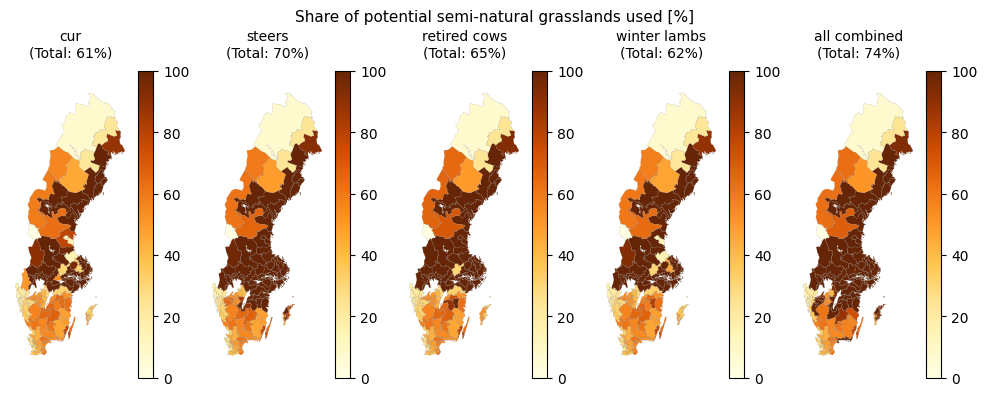

In [58]:
sng_use = session.get_attr('c','area',{'crop':'land_use', 'region':None}).loc[scn_final,'semi-natural grasslands']
sng_pot = session.get_attr('r','max_land_use',['land_use','region']).loc[scn_final,'semi-natural grasslands']
tot_share = (sng_use.sum(axis=1) / sng_pot.sum(axis=1)).droplevel('year')*100

plot_data = (
    (sng_use / sng_pot)
    .drop('baseline', level='scn')
    .droplevel('year')
) * 100

fig, axs = plt.subplots(1,len(plot_data), figsize=(10,4))
for n, scn in enumerate(plot_data.index):
    ax = axs[n]
    cm.plot.map_from_series(
        plot_data.loc[scn],
        ax = ax,
        vmin=0,
        vmax=100,
        **map_style
    )
    ax.set_title(f'{scn}\n(Total: {tot_share.loc[scn]:.0f}%)', size=10)
    ax.axis('off')
fig.suptitle('Share of potential semi-natural grasslands used [%]', size=11)
plt.tight_layout()
plt.show()

region                     1011          111          1111         1112  \
scn          year                                                         
cur          70    12270.744976  20009.44207  13051.596206  8625.978374   
             100   12270.744976  20009.44207  13051.596206  8625.978374   
             110   12270.744976  20009.44207  13051.596206  8625.978374   
steers       70    12270.744976  20009.44207  13051.596206  8625.978374   
             100   12270.744976  20009.44207  13051.596206  8625.978374   
             110   12270.744976  20009.44207  13051.596206  8625.978374   
retired cows 70    12270.744976  20009.44207  13051.596206  8625.978374   
             100   12270.744976  20009.44207  13051.596206  8625.978374   
             110   12270.744976  20009.44207  13051.596206  8625.978374   
winter lambs 70    12270.744976  20009.44207  13051.596206  8625.978374   
             100   12270.744976  20009.44207  13051.596206  8625.978374   
             110   12270.744976  20009.44207  13051.596206  8625.978374   
all combined 70    12270.744976  20009.44207  13051.596206  8625.978374   
             100   12270.744976  20009.44207  13051.596206  8625.978374   
             110   12270.744976  20009.44207  13051.596206  8625.978374   

region                      112         1121        1122         1123  \
scn          year                                                       
cur          70    16223.278507  4846.403328  9962.02009  3101.895482   
             100   16223.278507  4846.403328  9962.02009  3101.895482   
             110   16223.278507  4846.403328  9962.02009  3101.895482   
steers       70    16223.278507  4846.403328  9962.02009  3101.895482   
             100   16223.278507  4846.403328  9962.02009  3101.895482   
             110   16223.278507  4846.403328  9962.02009  3101.895482   
retired cows 70    16223.278507  4846.403328  9962.02009  3101.895482   
             100   16223.278507  4846.403328  9962.02009  3101.895482   
             110   16223.278507  4846.403328  9962.02009  3101.895482   
winter lambs 70    16223.278507  4846.403328  9962.02009  3101.895482   
             100   16223.278507  4846.403328  9962.02009  3101.895482   
             110   16223.278507  4846.403328  9962.02009  3101.895482   
all combined 70    16223.278507  4846.403328  9962.02009  3101.895482   
             100   16223.278507  4846.403328  9962.02009  3101.895482   
             110   16223.278507  4846.403328  9962.02009  3101.895482   

region                    1124          1131  ...           731           811  \
scn          year                             ...                               
cur          70    9141.437063  12388.128884  ...  14782.641483  34473.394048   
             100   9141.437063  12388.128884  ...  14782.641483  34473.394048   
             110   9141.437063  12388.128884  ...  14782.641483  34473.394048   
steers       70    9141.437063  12388.128884  ...  14782.641483  34473.394048   
             100   9141.437063  12388.128884  ...  14782.641483  34473.394048   
             110   9141.437063  12388.128884  ...  14782.641483  34473.394048   
retired cows 70    9141.437063  12388.128884  ...  14782.641483  34473.394048   
             100   9141.437063  12388.128884  ...  14782.641483  34473.394048   
             110   9141.437063  12388.128884  ...  14782.641483  34473.394048   
winter lambs 70    9141.437063  12388.128884  ...  14782.641483  34473.394048   
             100   9141.437063  12388.128884  ...  14782.641483  34473.394048   
             110   9141.437063  12388.128884  ...  14782.641483  34473.394048   
all combined 70    9141.437063  12388.128884  ...  14782.641483  34473.394048   
             100   9141.437063  12388.128884  ...  14782.641483  34473.394048   
             110   9141.437063  12388.128884  ...  14782.641483  34473.394048   

region                     812           813           814           821  \
scn          year           

In [14]:
plot_data

land_use          cropland                                        \
region                1011           111          1111      1112   
scn                                                                
cur          -2.366300e-01  3.672392e+00  1.469695e+00 -2.486386   
steers       -1.944026e+00  3.672392e+00 -2.022478e-01 -4.342329   
retired cows -2.182787e-14  2.182787e-14 -7.275958e-14 -0.330742   
winter lambs -2.910383e-14  1.818989e-14 -1.018634e-13 -0.772377   
all combined -2.824756e-09 -8.151983e-10 -1.250693e-09 -3.296425   

land_use                                                              \
region                 112          1121          1122          1123   
scn                                                                    
cur           3.230614e-01 -4.678663e+00 -1.553887e+00  2.892435e+00   
steers        3.230614e-01 -7.332527e+00 -4.072241e+00  2.892435e+00   
retired cows -7.275958e-15 -2.910383e-14 -5.820766e-14 -7.275958e-15   
winter lambs -2.546585e-14 -3.637979e-14 -1.091394e-14  2.182787e-14   
all combined -9.507530e-10 -2.709503e+00 -1.991851e+00 -1.419678e-09   

land_use                                  ... semi-natural grasslands  \
region                1124          1131  ...                     731   
scn                                       ...                           
cur          -2.038094e-03 -2.466634e-02  ...                0.025768   
steers       -1.019134e+00 -4.662214e-01  ...                0.025768   
retired cows -3.274181e-14 -3.456080e-14  ...                0.000027   
winter lambs -1.637090e-14 -1.273293e-14  ...                0.000027   
all combined -2.386368e-01 -1.157594e-08  ...                0.000027   

land_use                                                                  \
region             811       812       813       814       821       831   
scn                                                                        
cur          -0.188283  0.001571  0.000022  0.000035  0.000072  0.000044   
steers       -0.188283  0.001571  0.000022  0.000035  6.485611  0.000044   
retired cows  0.002153  0.001570  0.000020  0.000031  0.000065  0.000045   
winter lambs  0.002153  0.001570  0.000020  0.000031  0.000065  0.000045   
all combined  0.002153  0.001570  0.818693  4.442192  6.485611  2.545000   

land_use                                      
region             911        912        913  
scn                                           
cur           0.000717   0.000386   0.000955  
steers        0.000717  10.822640  13.553432  
retired cows  0.000720   3.251803   0.000957  
winter lambs  0.000720   0.657452   0.000957  
all combined  0.000720  10.822640  17.857557  

[5 rows x 318 columns]

## Run scenarios (multi proc.)

In [7]:
# Import
from concurrent.futures import ProcessPoolExecutor, as_completed
from multi_proc import do_run

In [8]:
# Create list of scenarios to run
runs = [(s,y) for s,y in session.iterate('all')]
runs

[('baseline', '0'),
 ('cur', '70'),
 ('cur', '100'),
 ('cur', '110'),
 ('steers', '70'),
 ('steers', '100'),
 ('steers', '110'),
 ('retired cows', '70'),
 ('retired cows', '100'),
 ('retired cows', '110'),
 ('winter lambs', '70'),
 ('winter lambs', '100'),
 ('winter lambs', '110'),
 ('all combined', '70'),
 ('all combined', '100'),
 ('all combined', '110')]

In [9]:
%%time
# Do the multi-processing
with ProcessPoolExecutor(max_workers=8) as executor:
    
    futures = {executor.submit(do_run, scn_year) : scn_year for scn_year in runs}

    for future in as_completed(futures):
    
        scn, year = futures[future]
           
        try:
            t = future.result()
        except Exception as ee:
            print(f'(!!!) {scn}, {year} failed with the exception: {ee}')
        else:
            m = int(t/60)
            s = int(round(t - m*60))
            print(f'{scn}, {year} finished successfully in {m}min {s}s')
            
session.cache.clear()                  

baseline, 0 finished successfully in 3min 38s
steers, 110 finished successfully in 4min 18s
cur, 100 finished successfully in 4min 27s
steers, 70 finished successfully in 4min 39s
retired cows, 70 finished successfully in 4min 39s
cur, 70 finished successfully in 4min 42s
steers, 100 finished successfully in 4min 44s
cur, 110 finished successfully in 4min 49s
retired cows, 100 finished successfully in 2min 37s
retired cows, 110 finished successfully in 3min 52s
all combined, 110 finished successfully in 4min 1s
winter lambs, 70 finished successfully in 4min 38s
winter lambs, 110 finished successfully in 4min 22s
all combined, 70 finished successfully in 4min 20s
winter lambs, 100 finished successfully in 4min 27s
all combined, 100 finished successfully in 4min 28s
CPU times: total: 46.9 ms
Wall time: 10min 2s


## Run scenarios here

In [4]:
import sys
import os
import time
from contextlib import redirect_stdout, redirect_stderr
import numpy as np
import scipy
import cvxpy
import matplotlib.pyplot as plt
sys.path.insert(0, 'C:/Users/jnka0003/Git repos/CIBUSmod')
import CIBUSmod as cm
from CIBUSmod.utils.helpers import check_constraints

In [5]:
# Create session (Make sure that name and data_path match the notebook!)
session = cm.Session(
    name = 'FORMAS',
    data_path = 'C:\\Users/jnka0003/Git repos/CIBUSmod/data',
    data_path_scenarios = 'scenarios',
    data_path_output = 'output',
    timeout = 60 # Increase timeout to avoid failing to write if multiple processes try to write at the same time
)

In [27]:
# Instatiate Regions
regions = cm.Regions(
    par = cm.ParameterRetriever('Regions')
    settings = {'max_land_use_from_scenario_x0' : True}
)

# Instantiate DemandAndConversions
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever('DemandAndConversions')
)

# Instantiate CropProduction
crops = cm.CropProduction(
    par = cm.ParameterRetriever('CropProduction'),
    index = regions.data_attr.get('x0_crops').index
)    

# Instantiate AnimalHerds
# Each AnimalHerd object is stored in an indexed pandas.Series
herds = cm.make_herds(regions)

# Instantiate WasteAndCircularity
waste = cm.WasteAndCircularity(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('WasteAndCircularity')
)

# Instantiate WasteAndCircularity
waste = cm.WasteAndCircularity(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('WasteAndCircularity')
)

# Instantiate feed management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt')
)

# Instantiate by-product management
byprod_mgmt = cm.ByProductMgmt(
    demand = demand,
    herds = herds,
    par = cm.ParameterRetriever('ByProductMgmt')
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('ManureMgmt'),
    settings = {
        'NPK_excretion_from_balance' : True
    }
)

# Instantiate crop residue managment
crop_residue_mgmt = cm.CropResidueMgmt(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('CropResidueMgmt')
)

# Instantiate plant nutrient management
plant_nutrient_mgmt = cm.PlantNutrientMgmt(
    demand = demand,
    regions = regions,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('PlantNutrientMgmt')
)

# Instatiate machinery and energy management
machinery_and_energy_mgmt  = cm.MachineryAndEnergyMgmt(
    regions = regions,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('MachineryAndEnergyMgmt')
)

# Instatiate inputs management
inputs = cm.InputsMgmt(
    demand = demand,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('InputsMgmt')
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('GeoDistributor')
)

In [28]:
def _max_sng_obj(geodist):
    geodist.define_cvx_problem()

    # Get x variable
    x = geodist.problem.variables()[0]

    # Create objective
    rel = cm.ParameterRetriever.get_rel('crop','land_use')
    P = np.concatenate([
        np.zeros(len(geodist.x_idx_short['ani'])),
        np.array([1 if rel[cr] == 'semi-natural grasslands' else 0 for cr,_,_ in geodist.x_idx_short['crp']])
    ])
    obj = cvxpy.Maximize(
        cvxpy.sum(cvxpy.multiply(P, x))
    )
    
    # Create problem
    geodist.problem = cvxpy.Problem(
        objective = obj,
        constraints = geodist.problem.constraints
    )

In [29]:
def _make_ani_cons(geodist, name, M, b, rel):
    
    from CIBUSmod.optimisation.geo_dist import IndexedMatrix
    
    # Create A matrix
    M = scipy.sparse.csc_matrix(M)
    Z = scipy.sparse.csc_matrix((M.shape[0],len(geodist.x_idx_short['crp']))) # Zero matrix
    A = scipy.sparse.hstack([M,Z], format='csc')
    A = IndexedMatrix(
        matrix=A,
        row_idx=pd.Index([name]),
        col_idx={k:v.copy() for k,v in geodist.x_idx_short.items()}
    )
    
    # Append constraint
    geodist.constraints.update({f'{name}: A @ x {rel} b' : {
        'left' : lambda x,A: A.M @ x,
        'right' : lambda A: b,
        'rel' : rel,
        'pars' : {'A':A}
    }})

    return None

In [30]:
def _get_herds_par(herds, attr):
    
    res = pd.concat([
        pd.concat({h.species: 
            pd.concat({h.breed:
                pd.concat({h.prod_system:
                    pd.concat({h.sub_system:
                        h.data_attr.get(attr)
                    }, names=['sub_system'])
                }, names=['prod_system'])
            }, names=['breed'])
        }, names=['species'])
    for h in herds])

    return res

In [31]:
def _make_CH4_cons(geodist, feed_mgmt, baseline_CH4, factor):
    
    feed_mgmt.calculate2()
    
    # Get CH4 emissions per defining animal
    CH4 = _get_herds_par(herds, 'enteric_methane').sum(axis=1).reindex(geodist.x_idx_short['ani'])
    
    # Assert that indexes match
    assert (CH4.index == geodist.x_idx_short['ani']).all()
    
    _make_ani_cons(geodist, name='CH4', M=CH4, b=baseline_CH4 * factor, rel='<=')

    return None

In [32]:
def _make_milkmeat_cons(geodist, baseline_milkmeat):

    # Get milk and meat prod. per defining animal
    meat = _get_herds_par(herds, 'production').xs('meat', level='animal_prod', axis=1).sum(axis=1).xs('cattle', drop_level=False).reindex(geodist.x_idx_short['ani'], fill_value=0)
    milk = _get_herds_par(herds, 'production').xs('milk', level='animal_prod', axis=1).sum(axis=1).xs('cattle', drop_level=False).reindex(geodist.x_idx_short['ani'], fill_value=0)
    milkmeat = (milk - meat*baseline_milkmeat)
    _make_ani_cons(geodist, name='milk/meat', M=milkmeat, b=0, rel='==')

    return None

In [33]:
def _make_beeflamb_cons(geodist, baseline_beeflamb):

    # Get beef and lamb prod. per defining animal
    beef = _get_herds_par(herds, 'production').xs('meat', level='animal_prod', axis=1).sum(axis=1).xs('cattle', drop_level=False).reindex(geodist.x_idx_short['ani'], fill_value=0)
    lamb = _get_herds_par(herds, 'production').xs('meat', level='animal_prod', axis=1).sum(axis=1).xs('sheep', drop_level=False).reindex(geodist.x_idx_short['ani'], fill_value=0)
    beeflamb = (beef - lamb*baseline_beeflamb)
    _make_ani_cons(geodist, name='beef/lamb', M=beeflamb, b=0, rel='==')

    return None

In [35]:
# Create list of scenarios to run
runs = [(s,y) for s,y in session.iterate('cur')]
runs

[('cur', '70'), ('cur', '100'), ('cur', '110')]

In [37]:
for scn, year in runs:
    
    tic = time.time()
    scn_str = f'Scenario: {scn}, {year}'
    print(f'\n{"-"*len(scn_str)}\n{scn_str}\n{"-"*len(scn_str)}\n')
    
    # Update all parameter values
    cm.ParameterRetriever.update_all_parameter_values(
        **session[scn],
        year = year
    )
    
    # Get region attributes
    regions.calculate(verbose=True)
    
    # Calculate food demand
    demand.calculate(verbose=True)
    
    # Calculate crops
    crops.calculate(verbose=True)
    
    # Calculate herds
    for h in herds:
        h.calculate(verbose=True)
    
    # Calculate feed
    feed_mgmt.calculate(verbose=True)
    
    if scn != 'baseline':
        while True:
            try:
                # Get baseline crop areas, animal numbers and land use
                baseline_ani = session.get_attr('geo','x_animals', scn='baseline').iloc[0]
                baseline_crp = session.get_attr('geo','x_crops', scn='baseline').iloc[0]
                baseline_lu = session.get_attr('c','area',{'region':None, 'crop':'land_use'}, scn='baseline').iloc[0].unstack()
                # Get baseline CH4 emissions
                baseline_CH4 = session.get_attr(
                    'A', 'enteric_methane',
                    'none',
                    scn='baseline'
                ).iloc[0]
                # Get baseline milk/meat
                prod = session.get_attr('A', 'prod', ['species', 'animal_prod'], scn='baseline').iloc[0]
                baseline_milkmeat = prod[('cattle','milk')] / prod[('cattle','meat')]
                # Get baseline beef/lamb
                prod = session.get_attr('A', 'prod', ['species','animal_prod'], scn='baseline').iloc[0]
                baseline_beeflamb = prod[('cattle','meat')] / prod[('sheep','meat')]
            except:
                time.sleep(10)
            else:
                break
    
    # Distribute animals and crops
    # Make optimisation problem
    if scn == 'baseline':
        geodist.make(
            use_cons=[1,2,3,4,5,6,7],
            scale_power=0.4,
            verbose=True
        )
        # Solve optimisation problem
        geodist.solve(verbose=True)
    else:
        # Drop demand for cattle, sheep and horses
        demand.data_attr.update(
            'animal_prod_demand',
            demand.data_attr.get('animal_prod_demand')
            .loc[(slice(None),['pigs','poultry'],slice(None))]
        )
    
        # Set maximum cropland and greenhouse area to baseline levels
        regions.data_attr.get('max_land_use').update(baseline_lu.loc[:,['cropland','greenhouse']])
    
        # Baseline Semi-natural grassland areas
        C8_SNG_P = baseline_crp.copy()\
        .loc[['Semi-natural pastures']]
        C8_SNG_PWT = baseline_crp.copy()\
        .loc[['Semi-natural pastures, wooded','Semi-natural pastures, thin soils']]
        C8_SNG_M = baseline_crp.copy()\
        .loc[['Semi-natural meadows']]
        C8_FAL = baseline_crp.copy()\
        .loc[['Fallow', 'Ley not harvested']]# * 0.8
        C8_ani = baseline_ani.copy()
    
        geodist.make(
            use_cons=[1,2,3,4,5,6,7,8],
            scale_power=0.4,
            C8_crp = [ C8_SNG_P,   C8_SNG_PWT,   C8_SNG_M,   C8_FAL,   None                    ],
            C8_ani = [ None,       None,         None,       None,     C8_ani.loc[['horses']]  ],
            C8_rel = [ '>=',       '==',         '==',       '>=',     '=='                    ],
            verbose=True
        )
        
        # Add constraint on CH4 emissions and milk/meat
        CH4_factor = float(year)/100
        _make_CH4_cons(geodist, feed_mgmt, baseline_CH4, CH4_factor)
        _make_milkmeat_cons(geodist, baseline_milkmeat)
        _make_beeflamb_cons(geodist, baseline_beeflamb)
    
        # First we solve with the obejctive of maximising semi-natural grassland area
        _max_sng_obj(geodist)
        geodist.solve(apply_solution=False, verbose=True)
    
        # Get semi-natural grassland areas from first solution and add constraint on total
        # semi-natural grassland area for second optimization round
        sng_areas = geodist.x['crp'].loc[['Semi-natural pastures', 'Semi-natural pastures, thin soils', 'Semi-natural pastures, wooded']]
        geodist.make_C9(C9_crp = sng_areas * 0.99, C9_rel = '>=') # Introduce a fair bit of slack to avoid unfeasible model
        geodist.make_C7()
    
        # Drop semi-natural grasslands from objective
        cm.helpers.drop_from_objective(geodist, 'crp', 'Semi-natural pastures')
        cm.helpers.drop_from_objective(geodist, 'crp', 'Semi-natural pastures, thin soils')
        cm.helpers.drop_from_objective(geodist, 'crp', 'Semi-natural pastures, wooded')
    
        # Solve optimisation problem again, this time minimising deviation from current
        # crop areas and animal numbers
        geodist.define_cvx_problem()
        geodist.solve(verbose=True)
    
    # Redistribute feeds (not yet implemented) and calculate enteric CH4 emissions
    feed_mgmt.calculate2(verbose=True)
    
    # Balance by-product demand and suply
    byprod_mgmt.calculate(verbose=True)
    
    # Calculate manure
    manure_mgmt.calculate(verbose=True)
    
    # Calculate harvest of crop residues
    crop_residue_mgmt.calculate(verbose=True)
    
    # Calculate treatment of wastes and other feedstocks
    waste.calculate(verbose=True)
    
    # Calculate plant nutrient management
    plant_nutrient_mgmt.calculate(verbose=True)
    
    # Calculate energy requirements
    machinery_and_energy_mgmt.calculate(verbose=True)
    
    # Calculate inputs supply chain emissions
    inputs.calculate(verbose=True)
    
    # Store results (try again if first atempt fails)
    try:
        session.store(
            scn, year,
            demand, regions, crops, herds, waste, geodist
        )
    except:
        session.store(
            scn, year,
            demand, regions, crops, herds, waste, geodist
        )

    t = time.time() - tic
    m = int(t/60)
    s = int(round(t - m*60))
    print(f'{scn}, {year} finished successfully in {m}min {s}s')

    check_constraints(geodist)
    plt.show()


-----------------
Scenario: cur, 70
-----------------

[16:28:46][Regions] Getting initial crop areas and animal numbers (x0) ... 0.0s
[16:28:46][Regions] Getting climate and soil attributes ... 0.0s
[16:28:46][Regions] Calculating maximum land use ... 0.0s
[16:28:46][Regions] Done! Elapsed time: 0 sec
[16:28:46][DemandAndConversions] Calculating food demand ... 0.1s
[16:28:47][DemandAndConversions] Resolving recipies for compound foods ... 0.0s
[16:28:47][DemandAndConversions] Calculating waste ... 0.0s
[16:28:47][DemandAndConversions] Calculating product demand and generated by-products... 0.2s
[16:28:47][DemandAndConversions] Done! Elapsed time: 0 sec
[16:28:47][CropProduction] Calculating harvest ... 0.0s
[16:28:47][CropProduction] Calculating production ... 0.5s
[16:28:47][CropProduction] Calculating crop residues ... 0.0s
[16:28:47][CropProduction] Calculating seed demand ... 0.1s
[16:28:47][CropProduction] Done! Elapsed time: 1 sec
[16:28:47][AnimalHerd (cattle, beef, conventio

RuntimeError: No solution found!